In [27]:
import nibabel as nib

file_path = "/data/projects/depredict/repositories/EMBARC/data/data_bids/derivatives/_fmriprep/output/sub-CU0009/ses-1/func/sub-CU0009_ses-1_task-rest1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz"

img = nib.load(file_path)

print(img)

print(f"image shape: {img.shape} as (x, y, z, time)") # (x, y, z, time)?

<class 'nibabel.nifti1.Nifti1Image'>
data shape (97, 115, 97, 180)
affine: 
[[   2.     0.     0.   -96.5]
 [   0.     2.     0.  -132.5]
 [   0.     0.     2.   -78.5]
 [   0.     0.     0.     1. ]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  97 115  97 180   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1. 2. 2. 2. 2. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 2264.0027
cal_min         : -206.33665
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'xform matrices modified by FixHeaderApp

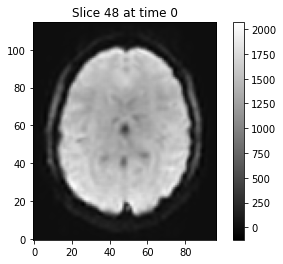

In [28]:
import matplotlib.pyplot as plt

# Converts to Matrix s
data = img.get_fdata()
#print(data)

t = 0
volume = data[:,:,:, t]

slice_idx = volume.shape[2] // 2
slice_data = volume[:, :, slice_idx]

plt.imshow(slice_data.T, cmap='gray', origin='lower')
plt.colorbar()
plt.title(f"Slice {slice_idx} at time {t}")
plt.show()

In [29]:
print(data)

[[[[0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   ...
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]]

  [[0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   ...
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]
   [0.00554568 0.00554568 0.00554568 ... 0.00554568 0.00554568
    0.00554568]]

  [[0.00554568 0.00554568 0.005545

In [31]:
import numpy as np

print(np.max(data))
print(np.mean(data))

2264.0025882422924
294.2184095346811


In [32]:
normalized_data = (data - np.min(data)) / (np.max(data) - np.min(data))

In [33]:
standardized_data = (data - np.mean(data)) / np.std(data)

In [34]:
print(normalized_data)

[[[[0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   ...
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]]

  [[0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   ...
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]
   [0.08352789 0.08352789 0.08352789 ... 0.08352789 0.08352789
    0.08352789]]

  [[0.08352789 0.08352789 0.083527

In [35]:
print(standardized_data)

[[[[-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   ...
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]]

  [[-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   ...
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53608501 -0.53608501
    -0.53608501]
   [-0.53608501 -0.53608501 -0.53608501 ... -0.53

In [37]:
print(np.max(normalized_data))
print(np.mean(normalized_data))

1.0
0.2026260473343017


In [38]:
print(np.max(standardized_data))
print(np.mean(standardized_data))

3.589142056143012
-2.437012996888874e-15


In [39]:
maxdiv_standardized_data = standardized_data / np.max(standardized_data)

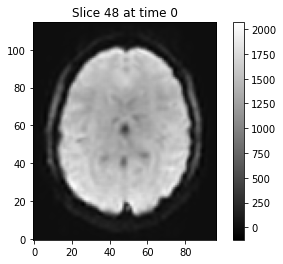

In [40]:


# Converts to Matrix s
maxdiv_data = img.get_fdata()
#print(data)

t = 0
volume = maxdiv_data[:,:,:, t]

slice_idx = volume.shape[2] // 2
slice_data = volume[:, :, slice_idx]

plt.imshow(slice_data.T, cmap='gray', origin='lower')
plt.colorbar()
plt.title(f"Slice {slice_idx} at time {t}")
plt.show()